In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


In [32]:
# Load the datasets
try:
    df_train = pd.read_csv('../data/train.csv')
    df_test = pd.read_csv('../data/test.csv') # The file without labels
    print(f"✅ Data Loaded.")
    print(f"Train Shape: {df_train.shape}")
    print(f"Test Shape:  {df_test.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Check your 'data' folder.")

print("\n--- Sample Data ---")
print(df_train.head(3))

✅ Data Loaded.
Train Shape: (165034, 14)
Test Shape:  (110023, 13)

--- Sample Data ---
   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   

   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0      0.0              2        1.0             0.0        181449.97       0  
1      0.0              2        1.0             1.0         49503.50       0  
2      0.0              2        1.0             0.0        184866.69       0  


In [33]:
drop_cols = ['id', 'CustomerId', 'Surname']

df_train_clean = df_train.drop(columns=drop_cols)
df_test_clean = df_test.drop(columns=drop_cols)

X = df_train_clean.drop('Exited', axis=1) # Features
y = df_train_clean['Exited']              # Target (1 = Churn, 0 = Stay)

# 4. Identify Categorical vs Numerical columns automatically
categorical_cols = ['Geography', 'Gender']
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                  'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

print("✅ Data Cleaned.")
print(f"Features: {X.columns.tolist()}")

✅ Data Cleaned.
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [34]:
# Split 80% Training, 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Rows: {X_train.shape[0]}")
print(f"Validation Rows: {X_val.shape[0]}")

Training Rows: 132027
Validation Rows: 33007


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=4, 
    random_state=42,
    eval_metric='logloss'
)

# 3. Create Pipeline
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)])

print("✅ Pipeline Created Successfully")

✅ Pipeline Created Successfully


In [36]:
print("⏳ Training Model...")
clf.fit(X_train, y_train)
print("✅ Training Complete!")

⏳ Training Model...
✅ Training Complete!


--- 📊 Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.82      0.87     26023
           1       0.54      0.80      0.64      6984

    accuracy                           0.81     33007
   macro avg       0.74      0.81      0.76     33007
weighted avg       0.85      0.81      0.82     33007

🌟 AUC-ROC Score: 0.8894


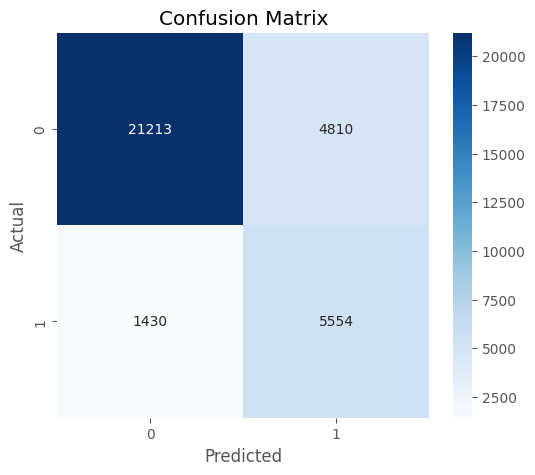

In [37]:
y_pred = clf.predict(X_val)
y_pred_proba = clf.predict_proba(X_val)[:, 1]

print("--- 📊 Classification Report ---")
print(classification_report(y_val, y_pred))

auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"🌟 AUC-ROC Score: {auc_score:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\Siddhesh\AppData\Local\Temp\ipykernel_13964\2061509760.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')


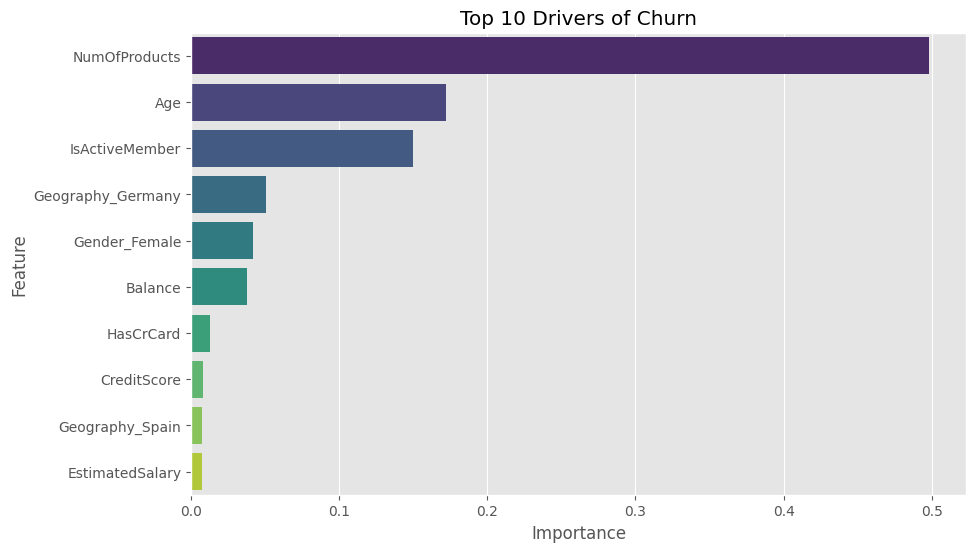

In [38]:
ohe_feature_names = clf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(ohe_feature_names)

importances = clf.named_steps['model'].feature_importances_

# Plot
feature_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Top 10 Drivers of Churn')
plt.show()

In [39]:
# 1. Predict on the REAL Test Data (test.csv)
test_probs = clf.predict_proba(df_test_clean)[:, 1]
test_preds = clf.predict(df_test_clean)

# 2. Create a clean results file
submission = df_test[['id', 'CustomerId', 'Surname', 'Geography', 'CreditScore']].copy()
submission['Predicted_Churn'] = test_preds
submission['Churn_Probability'] = test_probs

# 3. Save to CSV
submission.to_csv('../output/final_churn_predictions.csv', index=False)
print("✅ Predictions saved to '../output/final_churn_predictions.csv'")
print(submission.head())

✅ Predictions saved to '../output/final_churn_predictions.csv'
       id  CustomerId    Surname Geography  CreditScore  Predicted_Churn  \
0  165034    15773898   Lucchese    France          586                0   
1  165035    15782418       Nott    France          683                1   
2  165036    15807120         K?    France          656                0   
3  165037    15808905  O'Donnell    France          681                1   
4  165038    15607314    Higgins   Germany          752                1   

   Churn_Probability  
0           0.111241  
1           0.947905  
2           0.090657  
3           0.545526  
4           0.712344  
